Using device: cpu
📊 LOADING DATA
Train samples: 2041
Validation samples: 401
Test samples: 542
Number of classes: 105

📦 Creating DataLoaders...
Train batches: 128
Validation batches: 26
Test batches: 34

📐 MODEL ARCHITECTURE:
   Total parameters: 4,698,582
   Trainable parameters: 4,698,582

🚀 STARTING TRAINING (CPU MODE)
   Device: cpu
   Batch size: 16
   Max LR: 0.0003
   Epochs: 100
   Patience: 20
Epoch 001/100 | T-Loss: 4.7126 | T-Acc: 0.0136 | V-Loss: 4.5830 | V-Acc: 0.0299
  ✅ Best model saved! (Val Acc: 0.0299)
Epoch 002/100 | T-Loss: 4.6111 | T-Acc: 0.0205 | V-Loss: 4.5026 | V-Acc: 0.0499
  ✅ Best model saved! (Val Acc: 0.0499)
Epoch 003/100 | T-Loss: 4.5446 | T-Acc: 0.0279 | V-Loss: 4.4111 | V-Acc: 0.0599
  ✅ Best model saved! (Val Acc: 0.0599)
Epoch 004/100 | T-Loss: 4.4520 | T-Acc: 0.0536 | V-Loss: 4.2849 | V-Acc: 0.0773
  ✅ Best model saved! (Val Acc: 0.0773)
Epoch 005/100 | T-Loss: 4.3643 | T-Acc: 0.0768 | V-Loss: 4.1593 | V-Acc: 0.0923
  ✅ Best model saved! (Val Acc: 0

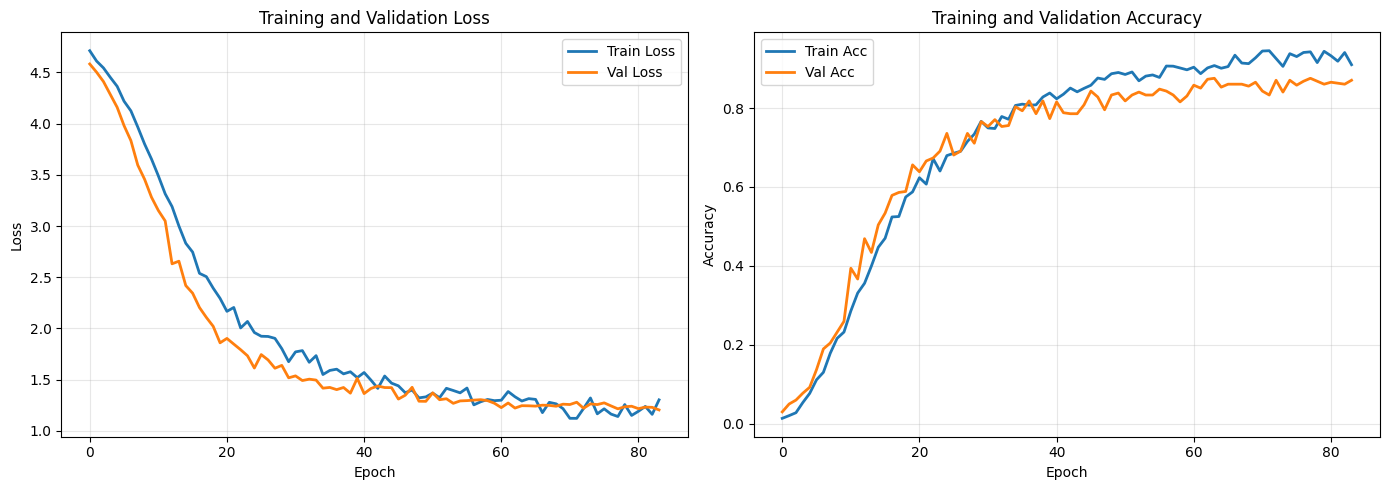

📊 Training curves saved to training_curves.png

📊 FINAL TEST EVALUATION


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import random
import matplotlib.pyplot as plt
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder

# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = Path("/kaggle/input/datasets/mariamhany44/100-words-preprocessed-landmarks-cleaned-no-mask")
BATCH_SIZE = 16  # Reduced for CPU
EPOCHS = 100  # Reduced for CPU
MAX_LR = 3e-4  # Lower learning rate for stability

# Force CPU usage (compatible with all systems)
DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

SEED = 42
MAX_FRAMES = 120
PATIENCE = 20

# ============================================================
# SEED EVERYTHING FOR REPRODUCIBILITY
# ============================================================

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

# ============================================================
# DATA LOADING
# ============================================================

print("="*60)
print("📊 LOADING DATA")
print("="*60)

df = pd.read_csv(DATA_DIR / "splits/splits.csv")
df["filepath"] = df["filepath"].str.replace("\\", "/", regex=False)
df["full_path"] = df["filepath"].apply(lambda x: DATA_DIR / "splits" / x)

# Encode labels
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)

# Save label encoder
np.save("label_classes.npy", le.classes_)

# Split data
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Number of classes: {num_classes}")

# ============================================================
# DATASET CLASS WITH AUGMENTATION
# ============================================================

class ASLDataset(Dataset):
    def __init__(self, df, train=True):
        self.df = df
        self.train = train
        
    def pad_or_truncate(self, x):
        if x.shape[0] > MAX_FRAMES:
            return x[:MAX_FRAMES]
        elif x.shape[0] < MAX_FRAMES:
            pad = np.zeros((MAX_FRAMES - x.shape[0], x.shape[1]))
            return np.vstack([x, pad])
        return x
    
    def augment(self, x):
        if self.train:
            # Spatial scaling
            if random.random() < 0.5:
                scale = np.random.uniform(0.85, 1.15)
                x = x * scale
            # Pointwise jitter
            if random.random() < 0.4:
                x += np.random.normal(0, 0.002, x.shape)
            # Time masking (drop random frames)
            if random.random() < 0.3:
                mask_len = int(MAX_FRAMES * 0.1)
                start = random.randint(0, MAX_FRAMES - mask_len)
                x[start:start+mask_len] = 0
        return x
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(row["full_path"])
        x = self.pad_or_truncate(x)
        x = self.augment(x)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(row["label_id"])

# ============================================================
# CREATE DATALOADERS
# ============================================================

print("\n📦 Creating DataLoaders...")

# Calculate class weights for balanced sampling
class_counts = (
    train_df["label_id"]
    .value_counts()
    .reindex(range(num_classes), fill_value=0)
    .values
)
class_weights = 1.0 / (class_counts + 1e-6)
sample_weights = train_df["label_id"].map(lambda x: class_weights[x]).values
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(
    ASLDataset(train_df, train=True), 
    batch_size=BATCH_SIZE, 
    sampler=sampler,
    num_workers=0
)
val_loader = DataLoader(
    ASLDataset(val_df, train=False), 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)
test_loader = DataLoader(
    ASLDataset(test_df, train=False), 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============================================================
# MODEL DEFINITION (CPU-OPTIMIZED)
# ============================================================

class ResidualBlock(nn.Module):
    def __init__(self, dim, drop_path=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(dim, dim, 3, padding=1, groups=dim),  # Depthwise
            nn.Conv1d(dim, dim, 1),  # Pointwise
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(drop_path),
            nn.Conv1d(dim, dim, 3, padding=1),
            nn.BatchNorm1d(dim)
        )
    
    def forward(self, x): 
        return x + self.conv(x)


class ASLModel(nn.Module):
    def __init__(self, input_dim=438, num_classes=105):
        super().__init__()
        
        # Input normalization
        self.input_bn = nn.BatchNorm1d(input_dim)
        
        # Stem convolution
        self.stem = nn.Sequential(
            nn.Conv1d(input_dim, 256, 7, padding=3),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        
        # Residual blocks
        self.res_layers = nn.Sequential(*[ResidualBlock(256) for _ in range(3)])
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            256, 256, num_layers=2, 
            batch_first=True, 
            bidirectional=True, 
            dropout=0.3
        )
        
        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x shape: (batch, frames, features)
        x = x.transpose(1, 2)  # (batch, features, frames)
        x = self.input_bn(x)
        x = self.stem(x)
        x = self.res_layers(x)
        x = x.transpose(1, 2)  # (batch, frames, channels)
        
        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, frames, 512)
        
        # Attention pooling
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        
        return self.classifier(context)


# Initialize model
model = ASLModel(input_dim=438, num_classes=num_classes).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📐 MODEL ARCHITECTURE:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# ============================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer with weight decay
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=MAX_LR, 
    weight_decay=0.05,
    betas=(0.9, 0.999)
)

# OneCycleLR scheduler
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=MAX_LR, 
    steps_per_epoch=len(train_loader), 
    epochs=EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos'
)

# ============================================================
# TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(loader, model, optimizer, criterion, scheduler):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # Mixup augmentation
        if random.random() < 0.5:
            lam = np.random.beta(0.2, 0.2)
            perm = torch.randperm(x.size(0)).to(DEVICE)
            
            mixed_x = lam * x + (1 - lam) * x[perm]
            outputs = model(mixed_x)
            
            loss = lam * criterion(outputs, y) + (1 - lam) * criterion(outputs, y[perm])
            
            # Calculate accuracy with mixup
            correct += lam * (outputs.argmax(1) == y).sum().item()
            correct += (1 - lam) * (outputs.argmax(1) == y[perm]).sum().item()
        else:
            outputs = model(x)
            loss = criterion(outputs, y)
            correct += (outputs.argmax(1) == y).sum().item()
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item() * y.size(0)
        total += y.size(0)
    
    return total_loss / total, correct / total


def evaluate(loader, model, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * y.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)
    
    return total_loss / total, correct / total

# ============================================================
# TRAINING LOOP
# ============================================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING (CPU MODE)")
print("="*60)
print(f"   Device: {DEVICE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Max LR: {MAX_LR}")
print(f"   Epochs: {EPOCHS}")
print(f"   Patience: {PATIENCE}")
print("="*60)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0
patience_counter = 0

for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(train_loader, model, optimizer, criterion, scheduler)
    
    # Validate
    val_loss, val_acc = evaluate(val_loader, model, criterion)
    
    # Store history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    
    # Print progress
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"T-Loss: {train_loss:.4f} | T-Acc: {train_acc:.4f} | "
          f"V-Loss: {val_loss:.4f} | V-Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_acc": val_acc,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "train_loss": train_loss,
            "label_classes": le.classes_,
            "num_classes": num_classes,
            "MAX_FRAMES": MAX_FRAMES
        }, "best_model.pth")
        
        print(f"  ✅ Best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
            break

# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

with open("training_history.json", "w") as f:
    json.dump(history, f)

print(f"\n💾 Training history saved to training_history.json")

# ============================================================
# PLOT TRAINING CURVES
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Val Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc", linewidth=2)
plt.plot(history["val_acc"], label="Val Acc", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print("📊 Training curves saved to training_curves.png")

# ============================================================
# FINAL TEST EVALUATION
# ============================================================

print("\n" + "="*60)
print("📊 FINAL TEST EVALUATION")
print("="*60)

# Load best model
checkpoint = torch.load("best_model.pth", map_location=torch.device('cpu'))
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Evaluate on test set
test_loss, test_acc = evaluate(test_loader, model, criterion)
print(f"\n🎯 Test Set Results:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ============================================================
# PER-CLASS ACCURACY
# ============================================================

def per_class_accuracy(loader, model, num_classes):
    model.eval()
    class_correct = torch.zeros(num_classes)
    class_total = torch.zeros(num_classes)
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            _, predicted = outputs.max(1)
            
            for i in range(len(y)):
                label = y[i]
                class_correct[label] += (predicted[i] == label).item()
                class_total[label] += 1
    
    return class_correct / (class_total + 1e-6)

print(f"\n📈 Per-Class Accuracy (first 20 classes):")
per_class_acc = per_class_accuracy(test_loader, model, num_classes)

for i in range(min(20, num_classes)):
    acc = per_class_acc[i].item()
    class_name = le.inverse_transform([i])[0]
    if len(class_name) > 30:
        class_name = class_name[:27] + "..."
    print(f"   {class_name:<30}: {acc:.4f} ({acc*100:.1f}%)")

# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

print(f"\n🔍 Sample Predictions (First 10 test samples):")
model.eval()
sample_count = min(10, len(test_loader.dataset))
correct_samples = 0

with torch.no_grad():
    for i, (x, y) in enumerate(test_loader):
        if i * BATCH_SIZE >= sample_count:
            break
        
        x, y = x.to(DEVICE), y.to(DEVICE)
        outputs = model(x)
        preds = outputs.argmax(1)
        
        for j in range(min(len(y), sample_count - i * BATCH_SIZE)):
            true_label = le.inverse_transform([y[j].item()])[0]
            pred_label = le.inverse_transform([preds[j].item()])[0]
            confidence = torch.softmax(outputs[j], dim=0)[preds[j]].item()
            
            correct = "✓" if y[j] == preds[j] else "✗"
            if y[j] == preds[j]:
                correct_samples += 1
            
            true_display = true_label[:35] + "..." if len(true_label) > 35 else true_label
            pred_display = pred_label[:35] + "..." if len(pred_label) > 35 else pred_label
            
            print(f"   {correct} True: {true_display:<35} | Pred: {pred_display:<35} | Conf: {confidence:.3f}")

print(f"\nSample accuracy: {correct_samples}/{sample_count} ({correct_samples/sample_count*100:.1f}%)")

# ============================================================
# SAVE FINAL RESULTS
# ============================================================

results = {
    "best_val_acc": best_val_acc,
    "test_acc": test_acc,
    "test_loss": test_loss,
    "num_classes": num_classes,
    "max_frames": MAX_FRAMES,
    "batch_size": BATCH_SIZE,
    "epochs_completed": len(history["train_loss"]),
    "total_params": total_params,
    "trainable_params": trainable_params
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\n💾 Results saved to results.json")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"\n📊 Final Summary:")
print(f"   Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Total Parameters: {total_params:,}")
print(f"   Training Samples: {len(train_df)}")
print(f"   Number of Classes: {num_classes}")
print(f"\n💾 Saved files:")
print(f"   - best_model.pth (best model weights)")
print(f"   - training_history.json (loss and accuracy history)")
print(f"   - training_curves.png (training plots)")
print(f"   - label_classes.npy (label encoder)")
print(f"   - results.json (final results)")
print("="*60)